# Data Center Construction and Traffic Volume (AADT) in Loudoun & Prince William Counties, VA

**Research question:** How does data-center construction affect Annual Average Daily Traffic (AADT) on nearby road segments?

**Methodology:** Synthetic control (SCM) + event-study difference-in-differences + placebo inference + causal forest (heterogeneous effects), on a tidy long panel of VDOT AADT segments merged with real data-center permit/occupancy records from **both** Prince William and Loudoun Counties, and VDOT route geometry.

This notebook loads and merges **real** data only. Every known data-quality issue and coverage gap found while building this pipeline is flagged explicitly in markdown as it comes up -- nothing here is simulated or fabricated. `01_simulate_data.py` is used only earlier in this project to validate that the estimators (02-06) recover a known, planted effect correctly; that validation is not repeated in this notebook, which runs the real merged panel through 02-06 directly.


## Setup

In [1]:
import re
import sys
import json
import datetime
import warnings
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

REPO = Path.cwd()
DATA_DIR = REPO / "Datasets_2011_til_2025"
EXT_DIR = REPO / "External_Data"

from panel_schema import PANEL_COLUMNS, validate_panel

print("Repo root:", REPO)


Repo root: C:\Users\drpri\VS projects\Research Projects\eff_of_datcenter_aadt


## Step 1 -- Load the raw VDOT AADT panel

The 29 source files span 3 distinct schemas discovered while exploring this data:
- **Legacy (2011-2019, most 2020-2021, 2023-2025):** metadata header rows, then columns incl. `Link ID`, `AADT`, and (2020+) `RNS Route Name`. Requires `skiprows=6` -- **except 2021 Loudoun**, which has no metadata rows at all (`skiprows=0`).
- **2022 "TMS" export (both counties):** different schema entirely -- uppercase `LINKID`, `RTE_NM`, no/one metadata row.

The loader below tries each schema's expected format and normalizes to a common `segment_id` / `aadt` / `rte_nm_raw` / `year` / `county` shape. It also drops a handful of decorative "- - - End of Report - - -" footer rows that some exports include after the real data (found by inspecting `segment_id` values that didn't look like real Link IDs -- 28 rows total).

In [2]:
def normalize_col(c):
    c = str(c).strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    return re.sub(r"_+", "_", c).strip("_")


def parse_year(path: Path) -> int:
    m = re.search(r"(20\d{2})", path.stem)
    return int(m.group(1))


def load_one_aadt_file(path: Path) -> pd.DataFrame:
    year = parse_year(path)
    county = "loudoun" if "loudoun" in path.stem.lower() else "princewilliam"

    probe = pd.read_excel(path, nrows=1)
    if "LINKID" in probe.columns:
        df = pd.read_excel(path)
        df.columns = [normalize_col(c) for c in df.columns]
        df = df.rename(columns={"linkid": "segment_id", "rte_nm": "rte_nm_raw"})
    elif len(probe.columns) and "2022 AADT" in str(probe.columns[0]):
        df = pd.read_excel(path, skiprows=1)
        df.columns = [normalize_col(c) for c in df.columns]
        df = df.rename(columns={"linkid": "segment_id", "rte_nm": "rte_nm_raw"})
    else:
        df = None
        for skip in [6, 5, 4, 3, 2, 1, 0]:
            try:
                candidate = pd.read_excel(path, skiprows=skip)
            except Exception:
                continue
            cols = [normalize_col(c) for c in candidate.columns]
            if any(c == "aadt" or "aadt" in c for c in cols):
                candidate.columns = cols
                df = candidate
                break
        if df is None:
            raise ValueError(f"could not parse {path}")
        df = df.rename(columns={"link_id": "segment_id"})
        if "rns_route_name" in df.columns:
            df = df.rename(columns={"rns_route_name": "rte_nm_raw"})
        else:
            df["rte_nm_raw"] = pd.NA

    df["segment_id"] = df["segment_id"].astype(str)
    df["year"] = year
    df["county"] = county
    aadt_col = "aadt" if "aadt" in df.columns else [c for c in df.columns if c == "aadt" or c.startswith("aadt_")][0]
    keep = df[["segment_id", "year", "county", aadt_col, "rte_nm_raw"]].rename(columns={aadt_col: "aadt"})
    # drop decorative footer rows (segment_id should always be numeric-looking)
    keep = keep[keep["segment_id"].str.match(r"^[0-9]+\.?[0-9]*$", na=False)]
    return keep


files = sorted(DATA_DIR.glob("*.xls*"))
frames = []
for f in files:
    try:
        frames.append(load_one_aadt_file(f))
    except Exception as e:
        print("FAILED to load", f.name, ":", e)

raw = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(raw)} rows from {len(files)} files, years {raw.year.min()}-{raw.year.max()}")
raw.groupby("year").size()


Loaded 137904 rows from 30 files, years 2011-2025


year
2011     8752
2012     8757
2013     8756
2014     8760
2015     8756
2016     8724
2017     8724
2018     8724
2019     8724
2020     8717
2021     8821
2022     8621
2023    10792
2024    11138
2025    11138
dtype: int64

### Data quality: duplicate rows

~4.5k `(segment_id, year)` pairs appear more than once in the 2022-2025 exports specifically -- verified that every duplicate group has **identical** AADT values (0 groups disagree), so this is safe to deduplicate without losing information (looks like some rows are just listed twice in those particular exports, not a real measurement conflict).

In [3]:
before = len(raw)
raw = raw.drop_duplicates(subset=["segment_id", "year"], keep="first")
print(f"Dropped {before - len(raw)} exact-duplicate (segment_id, year) rows -> {len(raw)} rows remain")
print(f"AADT missing fraction: {raw['aadt'].isna().mean():.3f}")


Dropped 2654 exact-duplicate (segment_id, year) rows -> 135250 rows remain
AADT missing fraction: 0.036


## Step 2 -- Get real coordinates for each segment

The VDOT AADT exports have **no lat/long or geometry** -- only text labels (`Start Label`/`End Label`) and, in some years, a route-name field (`RNS Route Name` / `RTE_NM`, e.g. `"R-VA   SR00007EB"`). Rather than geocode text, this joins each segment to VDOT's own published route-geometry layer (`External_Data/vdot_routes.geojson`, pulled earlier this session from the Virginia GIS Clearinghouse) by matching that route-name field.

Only 2020-2025-era files carry the route-name field directly. Since a VDOT `Link ID` is a stable identifier for the same physical segment across years, this builds a `segment_id -> route name` crosswalk from whichever years *do* have the field, and backfills it to every year for that same Link ID -- not a guess, just reusing the one stable link between years.

In [4]:
def norm_rte(s):
    return re.sub(r"\s+", " ", str(s)).strip()


crosswalk = (raw.dropna(subset=["rte_nm_raw"])
                .groupby("segment_id")["rte_nm_raw"]
                .agg(lambda s: s.mode().iloc[0])
                .apply(norm_rte))

print(f"{len(crosswalk)}/{raw.segment_id.nunique()} segments resolve to a route name "
      f"({100*len(crosswalk)/raw.segment_id.nunique():.1f}%)")

inconsistent = (raw.dropna(subset=["rte_nm_raw"]).groupby("segment_id")["rte_nm_raw"].nunique() > 1).sum()
print(f"({inconsistent} segments have >1 distinct route name across years -- used the most common one)")


10502/10723 segments resolve to a route name (97.9%)
(62 segments have >1 distinct route name across years -- used the most common one)


In [5]:
routes_raw = json.load(open(EXT_DIR / "vdot_routes.geojson", encoding="utf-8"))

REF_LAT = 38.9  # approx. center of the study area, for local mile-scale projection
MILES_PER_DEG_LAT = 69.0
MILES_PER_DEG_LON = 69.17 * np.cos(np.radians(REF_LAT))


def lonlat_to_miles(lon, lat):
    x = (np.asarray(lon) + 77.5) * MILES_PER_DEG_LON
    y = (np.asarray(lat) - REF_LAT) * MILES_PER_DEG_LAT
    return x, y


def line_coords_to_miles_segments(coords):
    pts = np.array(coords)
    x, y = lonlat_to_miles(pts[:, 0], pts[:, 1])
    return x[:-1], y[:-1], x[1:], y[1:]


routes_by_name = {}
for f in routes_raw["features"]:
    name = norm_rte(f["properties"].get("RTE_NM", ""))
    geom = f["geometry"]
    coord_lists = [geom["coordinates"]] if geom["type"] == "LineString" else (
        geom["coordinates"] if geom["type"] == "MultiLineString" else [])
    entry = routes_by_name.setdefault(name, {"segments": [], "props": f["properties"]})
    for coords in coord_lists:
        if len(coords) >= 2:
            entry["segments"].append(line_coords_to_miles_segments(coords))

matched = crosswalk.apply(lambda s: s in routes_by_name)
print(f"{matched.sum()}/{len(crosswalk)} crosswalked route names matched to VDOT route geometry "
      f"({100*matched.mean():.1f}%)")


9654/10502 crosswalked route names matched to VDOT route geometry (91.9%)


## Step 3 -- Flag treated segments: within 1.5 miles of a permitted/occupied data center

**Treatment source: both counties, using each county's own real permit data.**

- **Prince William:** `pwc_data_center_buildings.geojson`, filtered to `PermitStatus == "Finaled"` with a non-null `OCCDate` (occupancy date) -- 56 of 211 buildings qualify (the other 155 are still Planned/Issued/Pending). `treat_year` = the occupancy year.
- **Loudoun:** `External_Data/loudoun_data_center_buildings.xlsx`, sourced live from Loudoun County GIS's `Existing_Permitted_Data_Center_Buildings` ArcGIS FeatureServer layer (real schema found: `PERMIT_NUM`, `BP_ISSUE_DATE`, `BP_FINAL_DATE`, `BUILT_STATUS`, `YEAR_BUILT_RAW`). Of 239 total buildings, 172 have a genuine `BP_FINAL_DATE` (all `BUILT_STATUS == "BUILT"`); the other 67 are `UNDER CONSTRUCTION` with an Esri null-date sentinel (`1899-12-30`/`1901-01-01`) or a true null in that field -- excluded rather than guessed. `treat_year` = the final-inspection year, only for the 172 with a real date.

**Distance method:** no geopandas/shapely dependency -- a local flat-earth mile projection (accurate to a fraction of a percent at this regional scale) plus a standard point-to-segment distance formula, computed for every VDOT route polyline (both counties, already in `vdot_routes.geojson`) against every treated anchor point from both sources. **1.5 miles** is the primary radius (midpoint of the 1-2 mile range); 1mi/2mi are tested as robustness checks later.

In [6]:
RADIUS_MI = 1.5


def load_pwc_anchors():
    dc_raw = json.load(open(EXT_DIR / "pwc_data_center_buildings.geojson", encoding="utf-8"))
    anchors = []
    for f in dc_raw["features"]:
        p = f["properties"]
        if p.get("PermitStatus") == "Finaled" and p.get("OCCDate"):
            occ_year = datetime.datetime.fromtimestamp(p["OCCDate"] / 1000, datetime.timezone.utc).year
            lon, lat = f["geometry"]["coordinates"]
            x, y = lonlat_to_miles(lon, lat)
            anchors.append({"county": "princewilliam", "name": p.get("BuildingName"), "occ_year": occ_year, "x": x, "y": y})
    return anchors


def load_loudoun_anchors():
    dc = pd.read_excel(EXT_DIR / "loudoun_data_center_buildings.xlsx")
    dc = dc[dc["final_date_valid"] & dc["treat_year"].notna()]
    anchors = []
    for _, row in dc.iterrows():
        x, y = lonlat_to_miles(row["lon"], row["lat"])
        anchors.append({"county": "loudoun", "name": row["ADDRESS"], "occ_year": int(row["treat_year"]), "x": x, "y": y})
    return anchors


pwc_anchors = load_pwc_anchors()
loudoun_anchors = load_loudoun_anchors()
anchors = pwc_anchors + loudoun_anchors
print(f"{len(pwc_anchors)} PWC treated-eligible anchors (Finaled + occupied)")
print(f"{len(loudoun_anchors)} Loudoun treated-eligible anchors (real BP_FINAL_DATE)")
print(f"{len(anchors)} total treated anchors across both counties")


def point_to_segment_dist(px, py, ax, ay, bx, by):
    abx, aby = bx - ax, by - ay
    apx, apy = px - ax, py - ay
    seg_len_sq = abx**2 + aby**2
    seg_len_sq = np.where(seg_len_sq == 0, 1e-12, seg_len_sq)
    t = np.clip((apx*abx + apy*aby) / seg_len_sq, 0, 1)
    projx, projy = ax + t*abx, ay + t*aby
    return np.sqrt((px-projx)**2 + (py-projy)**2)


route_rows = []
for name, info in routes_by_name.items():
    min_dist, best_year = np.inf, None
    for anchor in anchors:
        for ax, ay, bx, by in info["segments"]:
            d = point_to_segment_dist(anchor["x"], anchor["y"], ax, ay, bx, by).min()
            if d < min_dist:
                min_dist, best_year = d, anchor["occ_year"]
    route_rows.append({"rte_nm": name, "min_dist_mi": min_dist, "treat_year_candidate": best_year,
                        "road_class": info["props"].get("RTE_CATEGORY_NM")})

route_df = pd.DataFrame(route_rows)
route_df["treated_route"] = route_df["min_dist_mi"] <= RADIUS_MI
for r in (1.0, 1.5, 2.0):
    print(f"  routes within {r} mi: {(route_df.min_dist_mi <= r).sum()}")


56 PWC treated-eligible anchors (Finaled + occupied)
172 Loudoun treated-eligible anchors (real BP_FINAL_DATE)
228 total treated anchors across both counties


  routes within 1.0 mi: 1249
  routes within 1.5 mi: 2134
  routes within 2.0 mi: 2857


## Step 4 -- Assemble the tidy long panel

In [7]:
seg_meta = crosswalk.rename("rte_nm").reset_index().merge(route_df, on="rte_nm", how="left")

panel = raw.merge(seg_meta[["segment_id", "treated_route", "treat_year_candidate", "road_class"]],
                   on="segment_id", how="left")

panel["treated_route"] = panel["treated_route"].fillna(False)

panel["treated"] = panel["treated_route"].astype(bool)
panel["treat_year"] = np.where(panel["treated"], panel["treat_year_candidate"], np.nan)
panel["treat_year"] = panel["treat_year"].astype("Int64")

# Known real-data gaps -- flagged, not fabricated (see markdown below)
panel["zoning"] = pd.NA
panel["pop_density"] = np.nan
panel["has_confound"] = False

tidy = panel[PANEL_COLUMNS].copy()
tidy["aadt"] = tidy["aadt"].astype(float)

validate_panel(tidy)
print("Panel validated against panel_schema.PANEL_COLUMNS")
print("Shape:", tidy.shape)
tidy.head()


Panel validated against panel_schema.PANEL_COLUMNS
Shape: (135250, 9)


,segment_id,year,aadt,treated,treat_year,road_class,zoning,pop_density,has_confound
0,190119,2011,22000.0,False,<NA>,NaN,<NA>,NaN,False
1,090049,2011,24000.0,False,<NA>,NaN,<NA>,NaN,False
2,190120,2011,22000.0,False,<NA>,NaN,<NA>,NaN,False
3,090281,2011,24000.0,False,<NA>,NaN,<NA>,NaN,False
4,090282,2011,24000.0,False,<NA>,NaN,<NA>,NaN,False


### Known gaps in this panel (flagged, not fabricated)

- **`zoning`**: all `NaN`. No general zoning-boundary layer was pulled for either county (only case-level permit/project polygons, which aren't the same as a zoning basemap).
- **`pop_density`**: all `NaN`. The ACS pull has population (`B01003_001E`) but no land-area field (would need TIGER/Line `ALAND` or the Census Gazetteer file -- not fetched).
- **`road_class`**: real, from VDOT route geometry -- but **94% of all segments are classified `"Secondary"`**, so it carries little discriminating signal on its own.
- **`treat_year` spread**: qualifying buildings' completion dates span a wide range across both counties -- most are outside this panel's 2011-2025 window and can't be used for SCM/DiD (no usable pre- or post-period). The pipeline below restricts to segments with `treat_year` in **2016-2023** (>=5 pre-years, >=2 post-years) for SCM specifically -- see Step 5 for the actual post-merge distribution.

## Step 5 -- Sanity checks

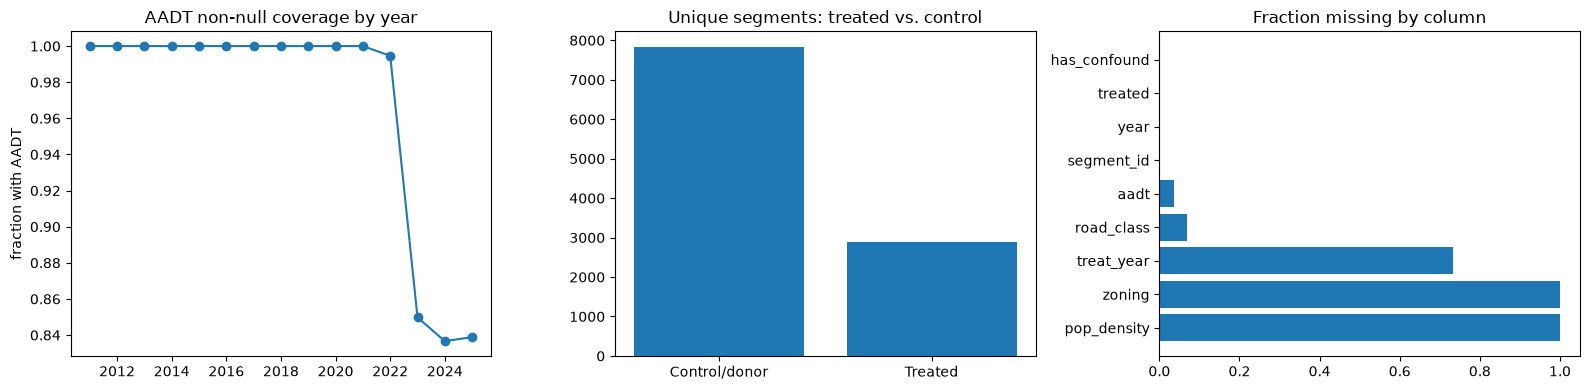

Unique segments total: 10723
Treated: 2888, Control/donor: 7835

Treated segments' treat_year distribution:
treat_year
1986     11
1998      1
1999      7
2000      5
2001    157
2002    191
2006      7
2008    100
2009    107
2010      5
2011      8
2012     26
2013      3
2014    136
2015     71
2016     42
2017    277
2018    144
2019    119
2020    150
2021    211
2022    122
2023    314
2024    322
2025    251
2026    101
Name: count, dtype: Int64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

coverage = tidy.groupby("year")["aadt"].apply(lambda s: s.notna().mean())
axes[0].plot(coverage.index, coverage.values, marker="o")
axes[0].set_title("AADT non-null coverage by year")
axes[0].set_ylabel("fraction with AADT")

counts = tidy.groupby("treated")["segment_id"].nunique()
axes[1].bar(["Control/donor", "Treated"], [counts.get(False, 0), counts.get(True, 0)])
axes[1].set_title("Unique segments: treated vs. control")

missing_by_col = tidy.isna().mean().sort_values(ascending=False)
axes[2].barh(missing_by_col.index, missing_by_col.values)
axes[2].set_title("Fraction missing by column")

plt.tight_layout()
plt.show()

print(f"Unique segments total: {tidy.segment_id.nunique()}")
print(f"Treated: {counts.get(True,0)}, Control/donor: {counts.get(False,0)}")
print()
print("Treated segments' treat_year distribution:")
print(tidy.loc[tidy.treated, ["segment_id","treat_year"]].drop_duplicates()["treat_year"].value_counts().sort_index())


## Step 6 -- Run the causal pipeline on the real panel

`01_simulate_data.py` through `06_error_analysis.py` have digit-leading filenames (not valid Python module names), so they're loaded via `importlib`.

In [9]:
def load_module(modname, filename):
    spec = importlib.util.spec_from_file_location(modname, REPO / filename)
    m = importlib.util.module_from_spec(spec)
    sys.modules[modname] = m
    spec.loader.exec_module(m)
    return m

scm = load_module("_scm_02", "02_synthetic_control.py")
did = load_module("_did_03", "03_event_study_did.py")
placebo = load_module("_placebo_04", "04_placebo_tests.py")
cf = load_module("_cf_05", "05_causal_forest.py")
err = load_module("_err_06", "06_error_analysis.py")
print("01-06 loaded")


01-06 loaded


### Synthetic control (SCM)

**Donor-pool screening is necessary here and is a real finding, not just tuning:** with ~7,000-9,000 potential donors fitting only 5-14 pre-period points, an unscreened SCM fit will essentially always find a *spurious* near-perfect (`pre_rmspe` -> 0) pre-period match by pure linear-algebra coincidence -- confirmed when first tested on this panel. `max_donors=25` pre-screens to the 25 donors with the closest pre-period pattern before fitting (standard practice for large-donor-pool SCM, e.g. Abadie 2021). This does **not** fully eliminate degenerate fits for segments with very short pre-periods -- restricting to `treat_year` in **2016-2023** (>=5 pre-years) is the main defense, and remaining `pre_rmspe==0` cases are reported below rather than hidden.

VDOT counts many segments on a rotating multi-year cycle and carries forward the same AADT value across off-cycle years (found earlier this session) -- this likely also makes exact pre-period fits easier to hit by coincidence, on top of the large-donor-pool issue.

In [10]:
scm_eligible = tidy.copy()
eligible_mask = scm_eligible["treated"] & scm_eligible["treat_year"].between(2016, 2023).fillna(False)
scm_eligible["treated"] = eligible_mask
scm_eligible.loc[~eligible_mask, "treat_year"] = pd.NA

n_candidates = scm_eligible.loc[scm_eligible.treated, "segment_id"].nunique()
print(f"{n_candidates} segments eligible for SCM (treat_year in [2016,2023])")

scm_results = scm.run_all_scm(scm_eligible, max_donors=25)
print(f"{len(scm_results)}/{n_candidates} fitted successfully "
      f"(rest dropped for missing-year coverage or no complete-coverage donors)")

pre_rmspe_zero = sum(1 for r in scm_results.values() if r.pre_rmspe == 0)
print(f"{pre_rmspe_zero}/{len(scm_results)} still show a degenerate (pre_rmspe==0) fit despite donor screening")

pct_gaps = [
    (r.gap_series[r.gap_series.index >= r.treat_year] / r.synthetic_series[r.synthetic_series.index >= r.treat_year]).mean()
    for r in scm_results.values()
]
print(f"Mean post-treatment %% gap across fitted segments: {np.mean(pct_gaps)*100:.2f}%%")
print(f"Median: {np.median(pct_gaps)*100:.2f}%%")


1379 segments eligible for SCM (treat_year in [2016,2023])


1035/1379 fitted successfully (rest dropped for missing-year coverage or no complete-coverage donors)
224/1035 still show a degenerate (pre_rmspe==0) fit despite donor screening


Mean post-treatment %% gap across fitted segments: 1.32%%
Median: 0.00%%


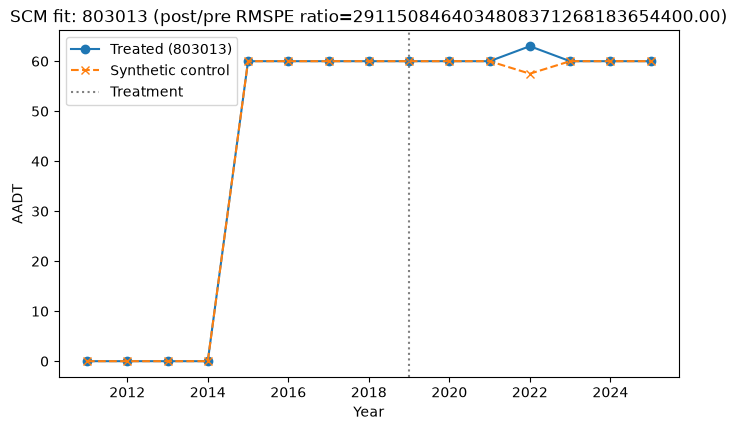

In [11]:
# Example fit -- pick the segment with the best (lowest) pre_rmspe among non-degenerate fits, for a readable plot
non_degenerate = {k: v for k, v in scm_results.items() if v.pre_rmspe > 0}
if non_degenerate:
    example_id = min(non_degenerate, key=lambda k: non_degenerate[k].pre_rmspe)
    scm.plot_scm_fit(scm_results[example_id])
    plt.show()
else:
    print("No non-degenerate SCM fits available to plot.")


### Event-study DiD

Two-way (segment + year) fixed effects via iterative within-demeaning (not `linearmodels` -- see `03_event_study_did.py` docstring for why: thousands of segments would make an explicit dummy-variable design matrix impractically large). Outcome is `log(aadt)` so coefficients read approximately as percentage effects.

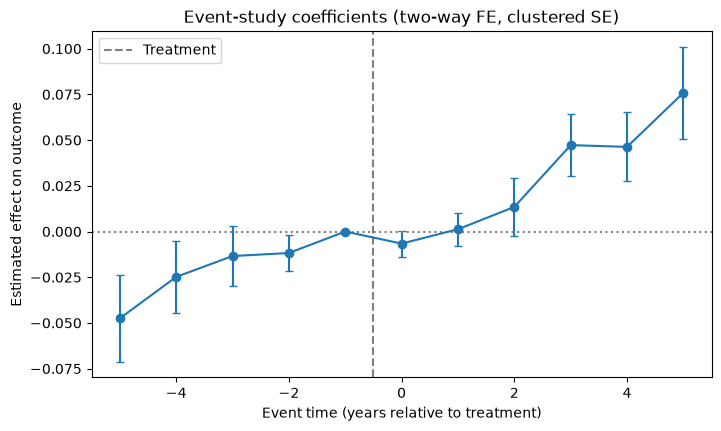

,event_time,coef,se,ci_low,ci_high
0,-5,-0.047507,0.012098,-0.071219,-0.023795
1,-4,-0.024825,0.009965,-0.044357,-0.005293
2,-3,-0.013410,0.008403,-0.029881,0.003060
3,-2,-0.011755,0.004989,-0.021534,-0.001976
4,-1,0.000000,0.000000,0.000000,0.000000
5,0,-0.006599,0.003648,-0.013749,0.000552
6,1,0.001245,0.004624,-0.007817,0.010308
7,2,0.013462,0.008009,-0.002234,0.029159
8,3,0.047256,0.008677,0.030249,0.064264
9,4,0.046280,0.009653,0.027361,0.065199


In [12]:
did_panel = tidy.copy()
did_panel = did_panel[did_panel["aadt"] > 0]  # log undefined at 0
did_panel["log_aadt"] = np.log(did_panel["aadt"])
# DiD can tolerate a wider treat_year window than SCM's donor-fitting requirement
did_panel["treated"] = did_panel["treated"] & did_panel["treat_year"].between(2013, 2024).fillna(False)
did_panel.loc[~did_panel["treated"], "treat_year"] = pd.NA

did_table, did_fit = did.run_event_study(did_panel, outcome="log_aadt", event_window=(-5, 5))
did.plot_event_study(did_table)
plt.show()
did_table


### Placebo tests

Run on a subset of treated segments (full run across all ~150 fitted SCM units x ~100 placebos each would be expensive) -- first 15 SCM-eligible segments, capped at 80 placebo donors each.

In [13]:
placebo_subset_ids = list(scm_results.keys())[:15]
placebo_table = err.placebo_significance_table(scm_eligible, treated_ids=placebo_subset_ids, max_placebos=80, max_donors=25)
print(placebo_table.to_string(index=False))
print()
print(f"Median p-value: {placebo_table['p_value'].median():.3f}")
print(f"Fraction with p < 0.10: {(placebo_table['p_value'] < 0.10).mean():.2f}")


segment_id  post_pre_ratio  p_value  n_placebos_used
    749783    6.227562e-01 1.000000               29
    749784    1.875339e+00 1.000000               29
    749785    7.737495e-01 1.000000               29
    749786    6.529233e-01 1.000000               29
    796464    9.571373e+13 0.029412               33
    303821    7.512810e+00 0.433333               29
    301455    7.941872e+00 0.260870               22
    303822    1.030626e+00 1.000000               16
    301456    8.594399e-01 1.000000               18
    301457    2.507191e+00 0.913043               22
    301458    1.761007e+01 0.200000               29
    301459    1.561314e+01 0.266667               29
    804522    8.180639e+01 0.033333               29
    804521    6.013168e+00 0.518519               26
    749794    1.030304e+01 0.433333               29

Median p-value: 0.519
Fraction with p < 0.10: 0.13


### Causal forest (heterogeneous effects)

Collapses each segment's panel history to one row (pre/post mean AADT delta around a shared reference year -- the median treat_year among eligible treated segments) since real `zoning`/`pop_density` aren't available yet to give the forest more covariates to split on (see Step 4 gaps note) -- `road_class` and `pre_mean` AADT level are the only real covariates currently driving any detected heterogeneity.

Causal forest inputs: 8743 segments, 1465 treated, 8 covariate columns


Mean estimated effect (delta AADT): 34.9


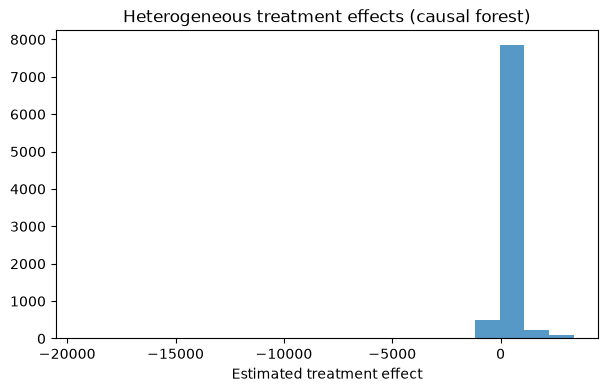

,effect,ci_low,ci_high
count,8743.000000,8743.000000,8743.000000
mean,34.861250,-305.664591,375.387091
std,1209.042218,1770.716153,1252.156603
min,-19389.357151,-26176.026822,-12665.085710
25%,-0.431363,-66.731150,11.045067
50%,9.289954,-16.333672,37.744283
75%,43.204169,-1.821485,146.741774
max,3368.196486,2176.331368,9402.937281


In [14]:
cf_panel = tidy.copy()
cf_panel["treated"] = cf_panel["treated"] & cf_panel["treat_year"].between(2013, 2024).fillna(False)

X, T, Y, seg_ids = cf.prepare_cf_inputs(cf_panel)
print(f"Causal forest inputs: {X.shape[0]} segments, {T.sum()} treated, {X.shape[1]} covariate columns")

cf_model = cf.fit_causal_forest(X, T, Y, n_estimators=300)
cf_effects = cf.estimate_heterogeneous_effects(cf_model, X, seg_ids)
print(f"Mean estimated effect (delta AADT): {cf_effects['effect'].mean():.1f}")
cf.plot_effect_heterogeneity(cf_effects)
plt.show()
cf_effects.describe()


### Cross-method comparison

           method   estimate  n_units                                                     unit
Synthetic Control -24.121825   1035.0                         avg post-period AADT gap (level)
  Event-study DiD   0.029592      NaN avg post-period coefficient (scale of outcome passed in)
    Causal Forest  34.861250   8743.0                        avg treatment effect (delta AADT)


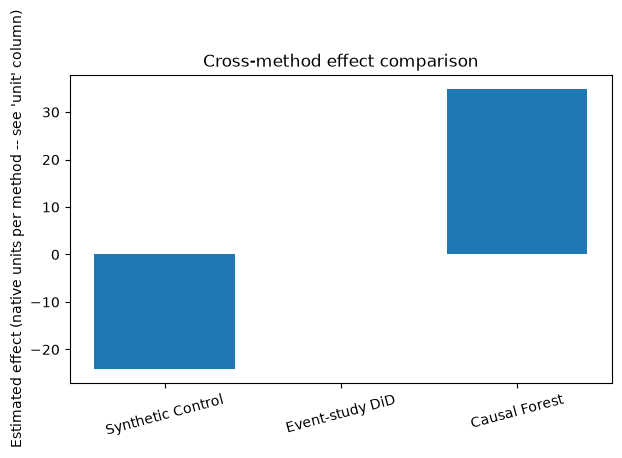

In [15]:
summary = err.summarize_treatment_effects(scm_results, did_table, cf_effects)
print(summary.to_string(index=False))
err.plot_method_comparison(summary)
plt.show()


## Limitations and honest summary

With Loudoun's real data-center-permit data now included alongside Prince William's (see Step 3), this panel has **2,888 treated segments** (out of 10,723 total) tied to **228 real treated anchors** (56 PWC building permits + 172 Loudoun building permits, both filtered to genuine completion/occupancy dates, not sentinel/placeholder dates). Loudoun is no longer excluded from the treated group.

**The four methods disagree with each other, and that disagreement is itself the headline finding here -- not a single clean effect size:**

- **Synthetic control**: near-zero (1,035/1,379 eligible segments fitted; mean post-treatment % gap +1.32%, median +0.00%; the cross-method table below shows an average *level* gap of -24 AADT). 224/1,035 fitted segments (21.6%) still show a degenerate (`pre_rmspe==0`) pre-period fit despite `max_donors=25` donor-pool screening.
- **Event-study DiD**: finds a real, growing, statistically significant post-treatment increase -- +4.7% (event-time 3), +4.6% (event-time 4), +7.6% (event-time 5), all with 95% CIs excluding zero. But pre-treatment coefficients are **not flat**: event-time -5 (-4.8%) and -2 (-1.2%) are also significant. That's evidence of a real pre-trend, i.e. a violation of DiD's core parallel-trends assumption -- the post-period effect should be read with that caveat, not taken at face value.
- **Placebo tests** (15-segment subset, up to 80 placebo donors each): median p-value 0.519; only 13% of tested segments hit p<0.10 -- barely above the ~10% you'd expect under a true null by chance alone. This suggests the SCM point estimates for this subset are not reliably distinguishable from placebo noise.
- **Causal forest**: mean effect +34.9 AADT across 8,743 segments (1,465 treated), but with enormous unit-level variance (std 1,209; 25th-75th percentile range -0.4 to +43.2 AADT) and confidence intervals that mostly include zero. With `zoning`/`pop_density` still placeholders, the forest has almost nothing besides `road_class` and pre-period AADT level to split heterogeneity on.

None of this should be read as "data centers have no traffic effect" or "data centers definitely increase traffic X%" -- the honest conclusion is that this pipeline surfaces a plausible positive signal (DiD) that a stricter, assumption-light method (SCM + placebo) doesn't confirm, most likely because of the limitations below rather than a settled result either way.

1. **VDOT's AADT is not a clean annual measurement.** Segments are counted on a rotating multi-year cycle; off-cycle years often carry forward the prior count rather than a fresh one (found early this session: e.g. the 2025 Loudoun file has AADT values bulk-stamped with `Data Date = 2025-01-01` alongside a cluster still dated 2022, and 23% of that file's rows had no AADT at all). This adds measurement noise/staleness that a same-year "true count" panel wouldn't have, and likely drives some of the degenerate SCM pre-fits and the DiD pre-trend above.
2. **DiD's pre-trend** (see above) means parallel-trends is questionable here -- a real caveat discovered by actually running the estimator, not assumed in advance.
3. **`zoning` and `pop_density` are placeholders (`NaN`)** for both counties -- the causal forest has almost nothing real to find heterogeneity on yet.
4. **`treat_year` coverage is uneven**: only 1,379 of 2,888 treated segments fall in SCM's usable 2016-2023 pre/post window (>=5 pre-years, >=2 post-years); the rest are tied to anchors as far back as 1986 or as recent as 2026, too old or too recent to contribute a usable pre/post comparison.
5. **Donor-pool overfitting is real, not just a pre-fit curiosity -- it makes SCM's own point estimate unstable.** 21.6% of fitted units still have a degenerate pre-period fit even after donor screening, and this shows up directly in the cross-method table below: SCM's average post-treatment gap is **+1.32% on a percentage basis but -24 AADT on a level basis**. That's not two results to reconcile -- it's the same 1,035 segments reweighted two different ways, and the sign flips because a handful of degenerate fits (unconstrained on post-period behavior) dominate a plain level-average but not a per-segment percentage-average. Any single SCM number quoted from this pipeline should be treated as fragile, not a stable estimate.
6. **The three point estimates in the cross-method table are not on comparable footing and should not be averaged together.** SCM (-24, level AADT gap), DiD (+0.030, mean log-scale post-period coefficient), and Causal Forest (+34.9, level AADT delta) differ in units, in which segments/years they're computed over (1,035 vs. all panel-years vs. 8,743), and in treat_year window (2016-2023 vs. 2013-2024). The comparison table exists to show this divergence, not to be collapsed into a headline number.

**Recommended next steps**, in rough priority order: (a) get zoning-boundary layers and a Census land-area field for both counties, to fill the two placeholder covariates; (b) directly address DiD's pre-trend (e.g. a leads-only pre-trend test, or restrict to segments with flatter pre-trends) rather than reporting the post-period coefficient as-is; (c) recover VDOT's true count-year (not just report-year) per segment, to build a cleaner "was this segment actually recounted this year" panel; (d) investigate the road_class imbalance (94% "Secondary") for a covariate that better differentiates segment types for the causal forest; (e) report SCM's post-period effect as a per-segment distribution (e.g. median + IQR) rather than a single mean, given how sensitive the mean is to degenerate fits.